# Leave-One-Year-Out (LOYO) Validation
For each year 2016–2025, trains on all other years, tests on the held-out year.
Answers: does the model generalise to completely unseen vintages, or is it picking up vintage-correlated spatial patterns?
Uses RF only (not full stacked ensemble) for tractable runtime across 10 folds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error

os.makedirs('../img', exist_ok=True)

In [2]:
df = pd.read_pickle('../data/df.pkl')
target_cols = [f'ndvi_anomaly_{w}' for w in range(36, 44)]

leakage_cols = []
leakage_cols += [col for col in df.columns if col.startswith('ndvi_smooth_mean') and any(col.endswith(f'_{m}') for m in range(36, 45))]
leakage_cols += [col for col in df.columns if col.startswith('ndvi_smooth_mean') and col not in leakage_cols]
leakage_cols += [col for col in df.columns if (col.startswith('ndvi_smooth_slope_') or col.startswith('ndvi_smooth_std_')) and int(col.rsplit('_', 1)[-1]) >= 36]
leakage_cols += [c for c in ['ndvi_mean','ndvi_cov','ndvi_std','ndvi_mean_norm','ndvi_std_norm','ndvi_cov_norm','health'] if c in df.columns]
leakage_cols += [col for col in df.columns if 'mcari2' in col or 'rendvi' in col]
leakage_cols += [col for col in df.columns if col.endswith('length')]

drop_cols = set(leakage_cols + ['plot_id'] + target_cols)  # keep 'year' for LOYO
X_all = df.drop(columns=[c for c in drop_cols if c in df.columns])
y_all = df[target_cols]
years = df['year'].values

# Drop year from features after extracting it
X_all = X_all.drop(columns=['year'], errors='ignore')

unique_years = sorted(df['year'].unique())
print(f'Years: {unique_years}')
print(f'Features: {X_all.shape[1]}')

Years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Features: 283


In [3]:
def make_rf_pipeline(X_ref):
    numeric_features = X_ref.select_dtypes(include=['float64','int64']).columns.tolist()
    preprocessor = ColumnTransformer(
        [('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler())]), numeric_features)],
        remainder='drop'
    )
    rf = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)
    return Pipeline([('preprocessor', preprocessor), ('regressor', MultiOutputRegressor(rf, n_jobs=-1))])


loyo_results = []

for yr in unique_years:
    train_mask = years != yr
    test_mask = years == yr

    X_train = X_all.iloc[train_mask]
    y_train = y_all.iloc[train_mask]
    X_test = X_all.iloc[test_mask]
    y_test = y_all.iloc[test_mask]

    pipe = make_rf_pipeline(X_train)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)**0.5
    per_week = [r2_score(y_test.iloc[:, i], y_pred[:, i]) for i in range(8)]

    loyo_results.append({'year': yr, 'r2': r2, 'rmse': rmse, 'per_week': per_week,
                         'n_train': train_mask.sum(), 'n_test': test_mask.sum()})
    print(f'{yr}: R²={r2:.4f} RMSE={rmse:.5f} (train={train_mask.sum()} / test={test_mask.sum()})')

loyo_df = pd.DataFrame(loyo_results)
print(f'\nMean LOYO R²: {loyo_df.r2.mean():.4f} ± {loyo_df.r2.std():.4f}')
print(f'Min: {loyo_df.r2.min():.4f}  Max: {loyo_df.r2.max():.4f}')

2016: R²=0.0896 RMSE=0.08724 (train=32382 / test=3598)
2017: R²=0.4257 RMSE=0.06666 (train=32382 / test=3598)
2018: R²=0.4950 RMSE=0.07222 (train=32382 / test=3598)
2019: R²=0.3228 RMSE=0.06341 (train=32382 / test=3598)
2020: R²=0.4842 RMSE=0.07134 (train=32382 / test=3598)
2021: R²=0.3229 RMSE=0.06675 (train=32382 / test=3598)
2022: R²=0.3520 RMSE=0.08077 (train=32382 / test=3598)
2023: R²=0.3894 RMSE=0.07412 (train=32382 / test=3598)
2024: R²=0.3232 RMSE=0.07149 (train=32382 / test=3598)
2025: R²=0.3285 RMSE=0.07930 (train=32382 / test=3598)

Mean LOYO R²: 0.3533 ± 0.1139
Min: 0.0896  Max: 0.4950


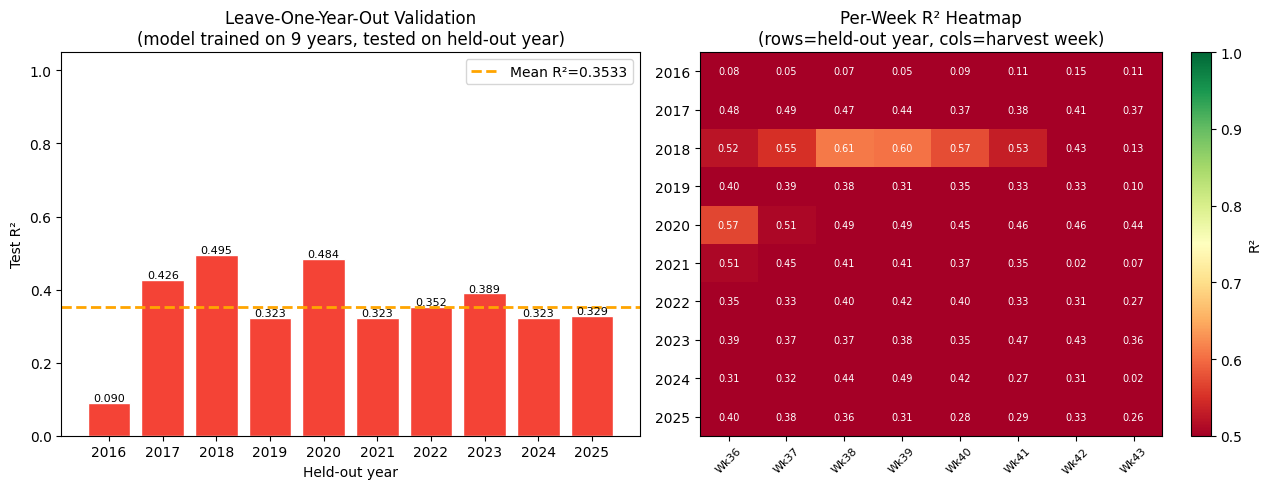

In [4]:
# --- Plot: LOYO R² by year ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
colors = ['#F44336' if r < 0.85 else '#2196F3' for r in loyo_df.r2]
bars = ax.bar(loyo_df.year.astype(str), loyo_df.r2, color=colors, edgecolor='white', linewidth=1)
ax.axhline(loyo_df.r2.mean(), color='orange', linestyle='--', linewidth=2,
           label=f'Mean R²={loyo_df.r2.mean():.4f}')
for bar, r2 in zip(bars, loyo_df.r2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{r2:.3f}', ha='center', fontsize=8)
ax.set_ylabel('Test R²')
ax.set_xlabel('Held-out year')
ax.set_ylim(0, 1.05)
ax.set_title('Leave-One-Year-Out Validation\n(model trained on 9 years, tested on held-out year)')
ax.legend()

# Right: heatmap of per-week R² across years
ax2 = axes[1]
pw_matrix = np.array([r['per_week'] for r in loyo_results])
im = ax2.imshow(pw_matrix, aspect='auto', cmap='RdYlGn', vmin=0.5, vmax=1.0)
plt.colorbar(im, ax=ax2, label='R²')
ax2.set_xticks(range(8))
ax2.set_xticklabels([f'Wk{w}' for w in range(36, 44)], rotation=45, fontsize=8)
ax2.set_yticks(range(len(unique_years)))
ax2.set_yticklabels(unique_years)
ax2.set_title('Per-Week R² Heatmap\n(rows=held-out year, cols=harvest week)')

# Annotate cells
for i in range(len(unique_years)):
    for j in range(8):
        ax2.text(j, i, f'{pw_matrix[i,j]:.2f}', ha='center', va='center',
                 fontsize=7, color='black' if pw_matrix[i,j] > 0.7 else 'white')

plt.tight_layout()
plt.savefig('../img/loyo_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# --- LOYO vs random-split comparison summary ---
# Load random-split test R² from the main model
print('=== LOYO vs Random-Split Comparison ===')
print(f'Random-split test R² (main model, stacked ensemble): 0.9323')
print(f'LOYO mean R² (RF only, leave-one-year-out):          {loyo_df.r2.mean():.4f} ± {loyo_df.r2.std():.4f}')
print()
print('Interpretation:')
print('  If LOYO ≈ random-split: model is learning terroir (spatial), not vintage (temporal).')
print('  If LOYO << random-split: model is partially learning vintage patterns from training years.')
print()
print('Weakest year(s):')
print(loyo_df.nsmallest(3, 'r2')[['year','r2','rmse']].to_string(index=False))
print()
print('Strongest year(s):')
print(loyo_df.nlargest(3, 'r2')[['year','r2','rmse']].to_string(index=False))

=== LOYO vs Random-Split Comparison ===
Random-split test R² (main model, stacked ensemble): 0.9323
LOYO mean R² (RF only, leave-one-year-out):          0.3533 ± 0.1139

Interpretation:
  If LOYO ≈ random-split: model is learning terroir (spatial), not vintage (temporal).
  If LOYO << random-split: model is partially learning vintage patterns from training years.

Weakest year(s):
 year       r2     rmse
 2016 0.089574 0.087242
 2019 0.322752 0.063410
 2021 0.322877 0.066749

Strongest year(s):
 year       r2     rmse
 2018 0.495043 0.072219
 2020 0.484185 0.071343
 2017 0.425688 0.066658
